# Seville fire weather — daily FWI, 1990–2025

**Source.** `cems-fire-historical-v1`, *Fire danger indices historical data from the
Copernicus Emergency Management Service*, hosted on the **CEMS Early Warning Data
Store** (`ewds.climate.copernicus.eu`) — a different portal from the CDS, with a
separate API key. GEFF model forced by ERA5, `system_version=4_1`,
`dataset_type=consolidated_dataset`, `product_type=reanalysis`.

Values are the mean over the 2×2 block of cells nearest 37.25°/37.50° N,
−6.00°/−5.75° E — the same block used for the heat indicators.

Produced by `fetch_seville_fire.py` (`fwi-download` → `fwi-subset`).

### Three things to keep in mind before reading any number here

**1. FWI is a noon-referenced index.** GEFF computes it from local-noon
temperature, relative humidity, wind and 24-h precipitation. Any comparison
against a daily maximum or a 6-hourly mean derived from raw ERA5 is comparing
different quantities, and the mismatch is systematic, not noise.

**2. The moisture codes have long memory, so daily *n* is not the sample size
you have.** The Drought Code has roughly a 52-day time constant and the Build-Up
Index inherits it. Lag-1 autocorrelation of daily FWI here is well above 0.9, so
a nominal 13,000 days is worth a few hundred independent observations. Every
correlation in the H2 section below is reported with a moving-block bootstrap
interval for exactly this reason; a textbook *p*-value on these series would be
wrong by orders of magnitude.

**3. `days_fwi_gt30` vs the EFFIS classes are different definitions.** The ECDE
indicator *days with high fire danger* counts FWI > 30. The EFFIS class
boundaries are 5.2 / 11.2 / 21.3 / 38.0 / 50.0. Both are computed below, and they
do not agree — 30 sits inside the EFFIS "high" band rather than at its edge.

### On the ECDE annual cross-check

The ECDE catalogue states that its fire variables (`days_with_high_fire_danger`,
`fire_weather_index`) come from *Fire danger indicators for Europe from 1970 to
2098 derived from climate projections* — the EURO-CORDEX SIS-Tourism product,
bias-corrected against reanalysis FWI over 1981–2010 — not from ERA5 directly.
If that holds, `origin='reanalysis'` is not a valid combination for those two
variables, and even where a series is returned it is a **different product
lineage** from the CEMS data above, not an independent check on it. Run
`python fetch_seville_fire.py ecde-check` to see the dataset's own constraints.
The last cell in this notebook compares the two series *if* the ECDE CSV exists,
and reports the bias rather than treating agreement as validation.

## What is FWI, and how is it computed?

The **Canadian Forest Fire Weather Index (FWI) System** estimates fire danger from **weather
alone** — no fuel type, vegetation, or topography input. Originally developed by the Canadian
Forest Service, it's the most widely used fire-danger rating system globally, and it's what EFFIS
(the European Forest Fire Information System) and Copernicus CEMS use for Europe. The data loaded
below comes from **GEFF** (Global ECMWF Fire Forecasting model) — ECMWF's implementation that
drives the Canadian system with ERA5 weather instead of Canadian station observations, which is
how a consistent global/European grid is produced.

### The four weather inputs

All taken at **local noon** — this is why the caveat below on comparing FWI against a daily max or
6-hourly ERA5 mean matters: those are different quantities, not noise.

- Temperature (°C)
- Relative humidity (%)
- Wind speed (km/h)
- 24-hour accumulated precipitation (mm)

### The six components, in three layers

**Layer 1 — three fuel moisture codes**, each representing a different fuel layer with a different
drying speed ("memory"):

| Code | Represents | Time constant | Meaning |
|---|---|---|---|
| **FFMC** (Fine Fuel Moisture Code) | Surface litter — leaves, twigs, needles | ~16 hours | Fast-responding; short-term ignition potential |
| **DMC** (Duff Moisture Code) | Loosely compacted organic layer | ~12 days | Medium memory; smoldering/spread potential |
| **DC** (Drought Code) | Deep, compact organic layer | **~52 days** | Long memory; seasonal drought effect, how hard deep fuel is to extinguish |

Each is computed **recursively**: today's value depends on yesterday's value plus today's
weather — rain wets the fuel back down (a rain-response formula), dry noon conditions dry it out
further (an exponential-decay-style formula). This recursive, long-memory structure is exactly the
mechanism behind the autocorrelation warning below — DC's ~52-day time constant is precisely why
lag-1 autocorrelation of the daily FWI series comes out above 0.9.

**Layer 2 — two intermediate indices**, combining the codes with wind:

- **ISI** (Initial Spread Index) = FFMC + wind speed → expected rate of fire spread
- **BUI** (Build-Up Index) = DMC + DC → total fuel available to feed a fire

**Layer 3 — the final index:**

- **FWI** = ISI + BUI → overall fire intensity, the general fire-danger number in the
  `fire_weather_index` column below

### How the classification below relates to this

The EFFIS class boundaries and the ECDE `days_with_high_fire_danger` threshold (both defined in
the constants cell below) are two *different* cuts through the same `fire_weather_index` values —
see caveat 3 below for why they disagree.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

pd.set_option("display.width", 140)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})

DATA = Path("data")
FWI_CSV  = DATA / "seville_fwi_daily_1990_2025.csv"
ERA5_CSV = DATA / "seville_era5_daily.csv"          # optional, for H2
ECDE_CSV = DATA / "seville_ecde_fire_annual_1990_2025.csv"   # optional

# EFFIS fire-danger class boundaries (FWI)
EFFIS = {"very low": 0.0, "low": 5.2, "moderate": 11.2,
         "high": 21.3, "very high": 38.0, "extreme": 50.0}
ECDE_HIGH_FWI = 30.0     # the ECDE 'days with high fire danger' threshold
FIRE_SEASON = (6, 9)     # Jun-Sep, EFFIS northern-hemisphere fire season

## 1. Load and integrity checks

In [2]:
fwi = pd.read_csv(FWI_CSV, parse_dates=["date"]).sort_values("date").set_index("date")
num = fwi.select_dtypes("number").columns.tolist()
print(fwi.dtypes.to_string())
print(f"\nrows: {len(fwi)}  span: {fwi.index.min().date()} .. {fwi.index.max().date()}")

full = pd.date_range(fwi.index.min(), fwi.index.max(), freq="D")
gaps = full.difference(fwi.index)
print(f"missing calendar days: {len(gaps)}"
      + (f"  first few: {[str(d.date()) for d in gaps[:5]]}" if len(gaps) else ""))
print(f"duplicate dates: {int(fwi.index.duplicated().sum())}")
print("\nnulls:\n" + fwi[num].isna().sum().to_string())

print("\nrange checks:")
for col, lo, hi in [("fire_weather_index", 0, np.inf),
                    ("fine_fuel_moisture_code", 0, 101),
                    ("drought_code", 0, np.inf),
                    ("build_up_index", 0, np.inf)]:
    if col in fwi:
        bad = int(((fwi[col] < lo) | (fwi[col] > hi)).sum())
        flag = "" if bad == 0 else "   <-- CHECK"
        print(f"  {col:26s} {bad} out-of-range{flag}")

cnt = fwi.groupby(fwi.index.year).size()
short = cnt[cnt < 365]
print("\nyears with fewer than 365 days:")
print(short.to_string() if len(short) else "  none")

city                             str
build_up_index               float64
drought_code                 float64
fine_fuel_moisture_code      float64
fire_weather_index           float64
initial_fire_spread_index    float64

rows: 13149  span: 1990-01-01 .. 2025-12-31
missing calendar days: 0
duplicate dates: 0

nulls:
build_up_index               0
drought_code                 0
fine_fuel_moisture_code      0
fire_weather_index           0
initial_fire_spread_index    0

range checks:
  fire_weather_index         0 out-of-range
  fine_fuel_moisture_code    0 out-of-range
  drought_code               0 out-of-range
  build_up_index             0 out-of-range

years with fewer than 365 days:
  none


A short final year is expected rather than an error: the consolidated dataset is
extended as ERA5 forcing becomes available, so the last year usually stops
mid-year. Drop it from any annual metric rather than letting a partial year sit
in a trend fit.

In [3]:
d = fwi[num].describe(percentiles=[.5, .9, .95, .99]).T
d["skew"] = fwi[num].skew()
d.round(2)

,count,mean,std,min,50%,90%,95%,99%,max,skew
build_up_index,13149.0,135.26,155.73,0.04,62.15,393.31,475.19,599.09,763.34,1.40
drought_code,13149.0,538.98,376.21,1.38,462.14,1101.63,1253.07,1488.60,1829.50,0.68
fine_fuel_moisture_code,13149.0,82.92,15.31,5.71,88.19,94.41,95.23,96.60,98.17,-2.03
fire_weather_index,13149.0,19.78,17.03,0.00,15.10,43.61,48.42,56.91,70.50,0.46
initial_fire_spread_index,13149.0,6.15,4.59,0.00,5.47,12.34,14.46,18.53,29.89,0.70


## 2. Annual aggregation

Several definitions on purpose. `fwi_season_mean` (Jun–Sep) is the one comparable
to published fire-season FWI figures; `days_fwi_gt30` is the ECDE-comparable
count; the EFFIS class counts are the ones tied to operational danger categories.

In [4]:
f = fwi["fire_weather_index"]
season = fwi[(fwi.index.month >= FIRE_SEASON[0]) & (fwi.index.month <= FIRE_SEASON[1])]
fs = season["fire_weather_index"]

ann = pd.DataFrame({
    "fwi_mean":             f.groupby(f.index.year).mean(),
    "fwi_p95":              f.groupby(f.index.year).quantile(0.95),
    "fwi_max":              f.groupby(f.index.year).max(),
    "fwi_season_mean":      fs.groupby(fs.index.year).mean(),
    "days_fwi_gt30":        (f > ECDE_HIGH_FWI).groupby(f.index.year).sum(),
    "days_high_effis":      (f > EFFIS["high"]).groupby(f.index.year).sum(),
    "days_very_high_effis": (f > EFFIS["very high"]).groupby(f.index.year).sum(),
    "days_extreme_effis":   (f > EFFIS["extreme"]).groupby(f.index.year).sum(),
})
if "drought_code" in fwi:
    ann["dc_season_mean"] = season["drought_code"].groupby(season.index.year).mean()
ann.index.name = "year"

# Drop any partial year so it cannot depress a trend line.
complete = cnt[cnt >= 365].index
dropped = sorted(set(ann.index) - set(complete))
if dropped:
    print(f"dropping incomplete year(s) from annual metrics: {dropped}")
    ann = ann.loc[ann.index.isin(complete)]

def longest_run(mask: pd.Series) -> int:
    best = cur = 0
    for v in mask:
        cur = cur + 1 if v else 0
        best = max(best, cur)
    return best

ann["longest_high_run"] = (f > EFFIS["high"]).groupby(f.index.year).apply(longest_run)
ann = ann.loc[ann.index.isin(complete)]
ann.round(1)

,fwi_mean,fwi_p95,fwi_max,fwi_season_mean,days_fwi_gt30,days_high_effis,days_very_high_effis,days_extreme_effis,dc_season_mean,longest_high_run
year,,,,,,,,,,
1990,17.6,43.2,57.5,34.8,108,152,46,4,861.4,92
1991,17.2,45.5,55.8,33.7,100,140,52,7,869.5,88
1992,19.8,47.8,64.1,31.6,112,153,63,13,858.5,86
1993,16.7,42.1,54.1,33.6,100,125,47,1,846.8,73
1994,20.7,47.1,70.5,39.0,116,162,68,13,897.5,119
1995,25.0,50.4,67.2,38.6,170,219,95,20,1209.5,58
1996,15.7,44.8,61.1,34.0,93,120,54,10,650.2,76
1997,17.7,44.6,61.7,31.6,102,156,57,12,731.0,32
1998,20.4,46.5,64.5,33.7,103,163,54,11,749.4,79


In [5]:
ann.to_csv("eda_results/eda_outputs/seville_fwi_annual.csv")
print(f"wrote eda_results/eda_outputs/seville_fwi_annual.csv ({ann.shape[0]} rows x {ann.shape[1]} cols)")

wrote eda_results/eda_outputs/seville_fwi_annual.csv (36 rows x 10 cols)


## 3. Trends

Same estimator set as the heat-indicator notebook: OLS for the familiar slope,
Theil–Sen for a slope that survives a couple of extreme years, Kendall's τ for a
rank test that makes no distributional assumption. On ~35 annual points with
autocorrelation, **read the Theil–Sen interval, not the OLS *p*-value.** Where the
two estimators disagree in sign or the Theil–Sen interval spans zero, the honest
conclusion is "no trend detected", not "a weak trend".

In [6]:
def trend_table(frame: pd.DataFrame, cols) -> pd.DataFrame:
    rows = []
    x = frame.index.values.astype(float)
    for col in cols:
        y = frame[col].astype(float).values
        ok = np.isfinite(y)
        ols = stats.linregress(x[ok], y[ok])
        ts = stats.theilslopes(y[ok], x[ok], 0.95)
        tau, ptau = stats.kendalltau(x[ok], y[ok])
        rows.append({
            "metric": col, "n": int(ok.sum()),
            "ols_per_decade": ols.slope * 10, "ols_p": ols.pvalue,
            "ols_r2": ols.rvalue ** 2,
            "theilsen_per_decade": ts[0] * 10, "ts_lo": ts[2] * 10, "ts_hi": ts[3] * 10,
            "kendall_tau": tau, "kendall_p": ptau,
        })
    out = pd.DataFrame(rows).set_index("metric")
    out["ts_excludes_zero"] = (out.ts_lo > 0) | (out.ts_hi < 0)
    out["sign_agreement"] = np.sign(out.ols_per_decade) == np.sign(out.theilsen_per_decade)
    return out

METRICS = ["fwi_mean", "fwi_season_mean", "fwi_p95", "days_fwi_gt30",
           "days_high_effis", "days_very_high_effis", "longest_high_run"]
tr = trend_table(ann, [m for m in METRICS if m in ann])
tr.round(3)

,n,ols_per_decade,ols_p,ols_r2,theilsen_per_decade,ts_lo,ts_hi,kendall_tau,kendall_p,ts_excludes_zero,sign_agreement
metric,,,,,,,,,,,
fwi_mean,36,0.410,0.387,0.022,0.354,-0.313,1.359,0.130,0.264,False,True
fwi_season_mean,36,0.467,0.429,0.018,0.597,-0.716,1.539,0.073,0.531,False,True
fwi_p95,36,-0.031,0.959,0.000,0.128,-1.259,1.636,0.010,0.935,False,False
days_fwi_gt30,36,4.175,0.256,0.038,5.000,-1.176,12.222,0.184,0.117,False,True
days_high_effis,36,3.516,0.389,0.022,4.533,-3.333,10.741,0.138,0.241,False,True
days_very_high_effis,36,2.066,0.585,0.009,4.180,-4.444,11.923,0.115,0.326,False,True
longest_high_run,36,6.009,0.129,0.066,5.872,-2.609,13.125,0.152,0.195,False,True


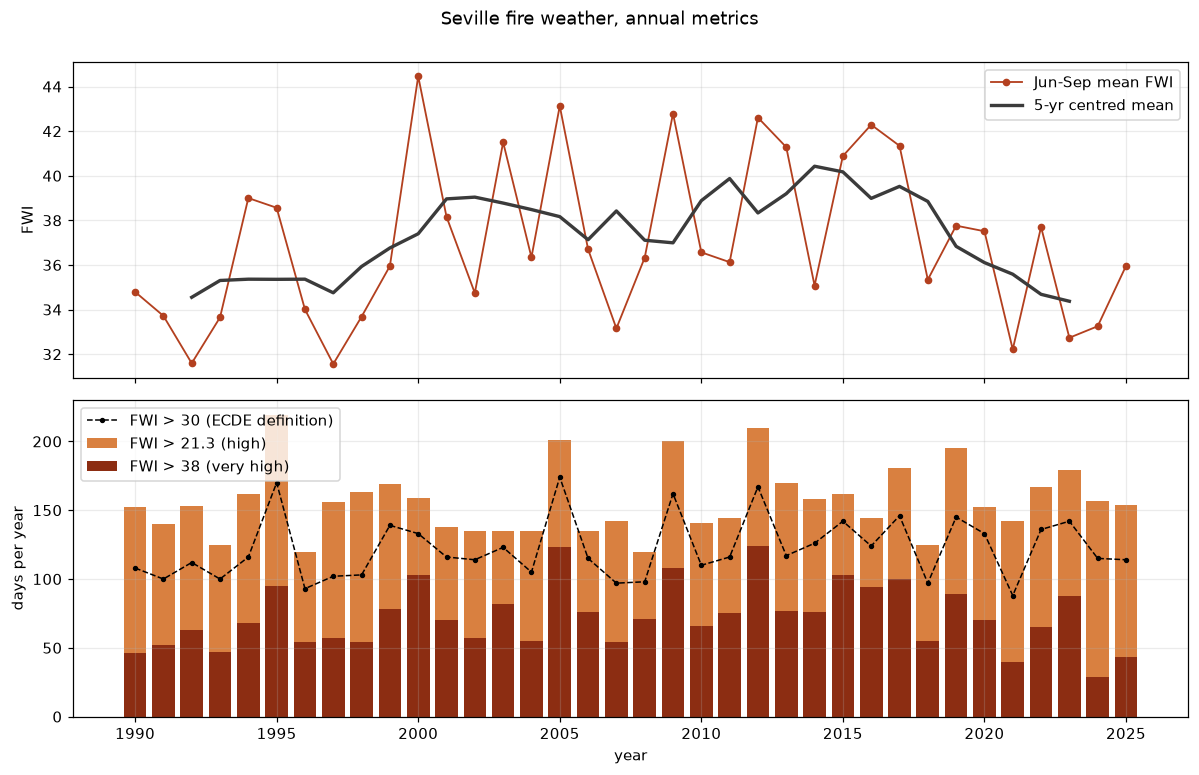

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(ann.index, ann.fwi_season_mean, "o-", lw=1.2, ms=4, color="#b3401f",
             label="Jun-Sep mean FWI")
axes[0].plot(ann.index, ann.fwi_season_mean.rolling(5, center=True).mean(),
             lw=2.2, color="#3b3b3b", label="5-yr centred mean")
axes[0].set_ylabel("FWI"); axes[0].legend()
axes[1].bar(ann.index, ann.days_high_effis, color="#d98040", label="FWI > 21.3 (high)")
axes[1].bar(ann.index, ann.days_very_high_effis, color="#8c2d12",
            label="FWI > 38 (very high)")
axes[1].plot(ann.index, ann.days_fwi_gt30, "k.--", lw=1, ms=5,
             label="FWI > 30 (ECDE definition)")
axes[1].set_ylabel("days per year"); axes[1].set_xlabel("year"); axes[1].legend()
fig.suptitle("Seville fire weather, annual metrics", y=1.00)
fig.tight_layout()

## 4. Seasonality and season length

The fire season is a result here, not an input. Jun–Sep is the EFFIS convention,
but the day-of-year climatology shows where Seville's danger window actually
sits, and whether it is widening.

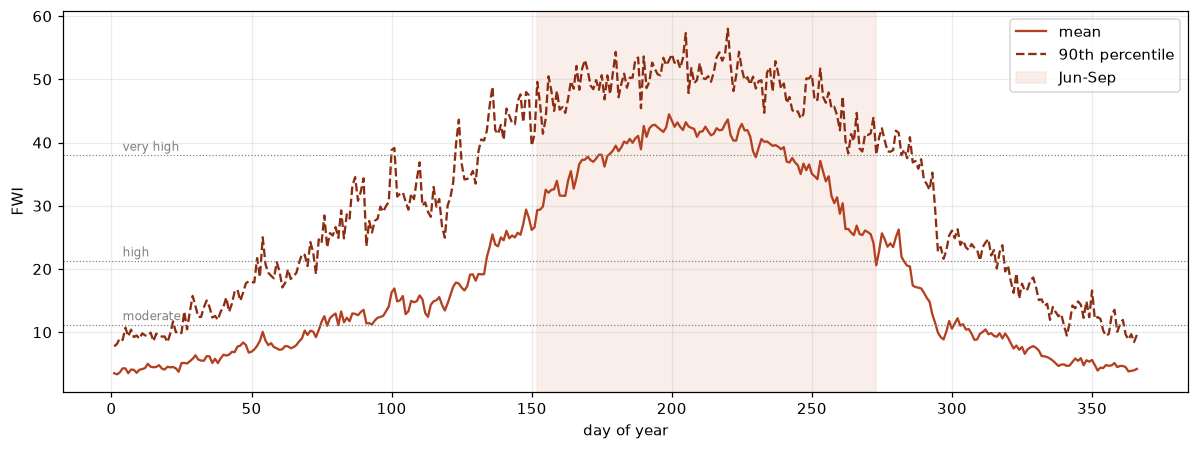

In [8]:
clim = f.groupby(f.index.dayofyear).agg(mean="mean", median="median",
                                        p90=lambda s: s.quantile(0.90))

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(clim.index, clim["mean"], color="#b3401f", label="mean")
ax.plot(clim.index, clim["p90"], color="#8c2d12", ls="--", label="90th percentile")
for name in ("moderate", "high", "very high"):
    ax.axhline(EFFIS[name], color="grey", lw=.8, ls=":")
    ax.text(4, EFFIS[name] + .7, name, fontsize=8, color="grey")
ax.axvspan(152, 273, color="#f0d0c0", alpha=.35, label="Jun-Sep")
ax.set_xlabel("day of year"); ax.set_ylabel("FWI"); ax.legend()
fig.tight_layout()

In [9]:
hi_days = f[f > EFFIS["high"]]
doy_by_year = hi_days.index.dayofyear.to_series(index=hi_days.index.year)
sb = pd.DataFrame({"first_high_doy": doy_by_year.groupby(level=0).min(),
                   "last_high_doy":  doy_by_year.groupby(level=0).max()})
sb.index.name = "year"
sb["high_season_span"] = sb.last_high_doy - sb.first_high_doy
sb = sb.loc[sb.index.isin(complete)]

sb.to_csv("eda_results/eda_outputs/seville_fwi_season_length_annual.csv")
print(f"wrote eda_results/eda_outputs/seville_fwi_season_length_annual.csv ({sb.shape[0]} rows x {sb.shape[1]} cols)")
print()
print("high-danger season, decade means:")
print(sb.groupby((sb.index // 10) * 10).mean().round(1).to_string())
print()
print(trend_table(sb, ["first_high_doy", "last_high_doy", "high_season_span"]).round(3).to_string())

wrote eda_results/eda_outputs/seville_fwi_season_length_annual.csv (36 rows x 3 cols)

high-danger season, decade means:
      first_high_doy  last_high_doy  high_season_span
year                                                 
1990            74.7          299.0             224.3
2000            84.4          302.7             218.3
2010            77.1          304.9             227.8
2020            71.0          311.2             240.2

                   n  ols_per_decade  ols_p  ols_r2  theilsen_per_decade   ts_lo   ts_hi  kendall_tau  kendall_p  ts_excludes_zero  sign_agreement
metric                                                                                                                                            
first_high_doy    36          -2.448  0.645   0.006               -2.971 -14.000   9.500       -0.062      0.595             False            True
last_high_doy     36           5.188  0.167   0.055                5.553  -1.176  13.214        0.198      0.091 

`first_high_doy` shifting earlier and `last_high_doy` later are separate claims
with separate evidence — a widening span can come from either end, and which end
it is matters for anything operational.

## 5. Autocorrelation: how much data is actually here

This cell is the justification for everything in section 6. If the effective
sample size is a small fraction of the nominal one, ordinary correlation
*p*-values on daily data are not merely optimistic, they are meaningless.

daily FWI lag-1 autocorrelation : 0.925
nominal n                       : 13149
effective n (AR1 approximation) : 513  (3.9% of nominal)
first lag with |ACF| < 0.2      : >60 days


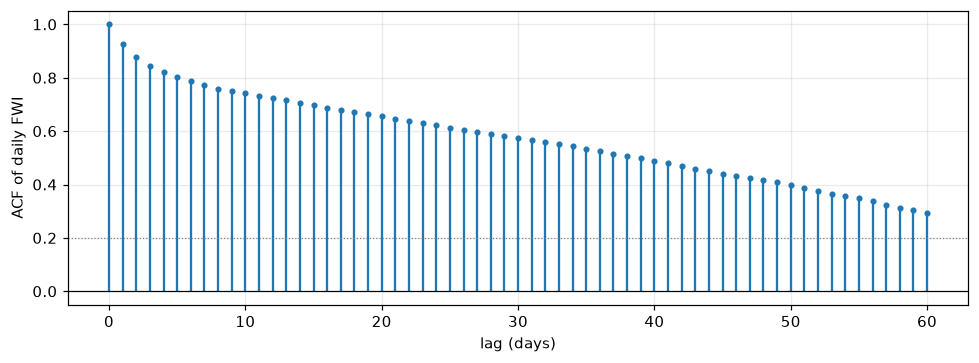

In [10]:
def acf(x, nlags=60):
    x = np.asarray(x, float); x = x - np.nanmean(x)
    den = np.nansum(x * x)
    return np.array([1.0] + [np.nansum(x[:-k] * x[k:]) / den for k in range(1, nlags + 1)])

a = acf(f.values, 60)
lag1 = a[1]
n_eff = len(f) * (1 - lag1) / (1 + lag1)
below = np.where(np.abs(a) < 0.2)[0]

print(f"daily FWI lag-1 autocorrelation : {lag1:.3f}")
print(f"nominal n                       : {len(f)}")
print(f"effective n (AR1 approximation) : {n_eff:.0f}  ({100*n_eff/len(f):.1f}% of nominal)")
print(f"first lag with |ACF| < 0.2      : "
      f"{int(below[0]) if len(below) else '>' + str(len(a)-1)} days")

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.stem(range(len(a)), a, basefmt=" ", markerfmt=".")
ax.axhline(0, color="k", lw=.8); ax.axhline(0.2, color="grey", ls=":", lw=.8)
ax.set_xlabel("lag (days)"); ax.set_ylabel("ACF of daily FWI")
fig.tight_layout()

In [11]:
def block_bootstrap_ci(x, y, block=30, n_boot=800, seed=0,
                       stat=lambda a, b: stats.spearmanr(a, b).statistic):
    """Moving-block bootstrap CI for a statistic on autocorrelated series.

    Resampling contiguous blocks preserves short-range dependence, so the
    interval reflects the number of *independent* stretches of data rather than
    the number of rows.
    """
    rng = np.random.default_rng(seed)
    x = np.asarray(x, float); y = np.asarray(y, float)
    ok = np.isfinite(x) & np.isfinite(y)
    x, y = x[ok], y[ok]
    n = len(x)
    if n <= block:
        return np.nan, (np.nan, np.nan)
    nblocks = int(np.ceil(n / block))
    out = np.empty(n_boot)
    for i in range(n_boot):
        s = rng.integers(0, n - block + 1, nblocks)
        idx = np.concatenate([np.arange(j, j + block) for j in s])[:n]
        out[i] = stat(x[idx], y[idx])
    return stat(x, y), tuple(np.percentile(out, [2.5, 97.5]))

## 6. H2 — daily FWI against daily heat and dryness

This section needs a daily ERA5 CSV at `DATA / "seville_era5_daily.csv"` with a
`date` column plus whatever heat/dryness fields you derived. It skips cleanly if
the file is absent. Adjust `HEAT_COLS` to your column names.

A fourth predictor, `spi3`, is joined in from `Calculating_SPI_for_Seville.ipynb`'s monthly
output — each day gets its calendar month's SPI-3 value. Unlike `t2m_max`/`rh_min`/`tp_mm`, which
are same-day snapshots, SPI-3 measures *accumulated* dryness over the preceding 3 months, which is
conceptually closer to what actually dries out fire fuel than a single day's weather. Note SPI-3 is
already deseasonalized by construction (it's a per-calendar-month standardized anomaly), so the
day-of-year anomaly framing below is somewhat redundant for it specifically — included anyway for a
like-for-like comparison against the other three predictors, which do need that step.

The four framings below answer progressively harder questions, and the numbers
drop sharply as you go down the list. That decline *is* the finding:

1. **Full year, raw** — inflated. Both series share an annual cycle, so this
   mostly measures "summer is hot and also flammable".
2. **Jun–Sep only** — removes most of the seasonal co-movement.
3. **Day-of-year anomalies** — removes the climatology from both sides. This is
   the one that tests whether an *unusually* hot, dry day is an *unusually*
   dangerous one.
4. **Lagged** — separates same-day flammability (FFMC-like, hours) from
   antecedent drying (DC-like, weeks). If lagged terms beat lag 0, the mechanism
   is accumulated dryness, not today's heat.

In [12]:
HEAT_COLS = ["t2m_max", "rh_min", "tp_mm", "spi3"]   # <-- edit to match your ERA5 CSV
SPI_CSV = Path("eda_results/eda_outputs/seville_spi3_monthly.csv")

if not ERA5_CSV.exists():
    print(f"[skip] no ERA5 daily CSV at {ERA5_CSV}")
    m = None
else:
    era = pd.read_csv(ERA5_CSV, parse_dates=["date"]).set_index("date")
    m = fwi.join(era, how="inner")

    # SPI-3 is monthly (from Calculating_SPI_for_Seville.ipynb) -- broadcast each month's
    # value onto every day in that month.
    if SPI_CSV.exists():
        spi = pd.read_csv(SPI_CSV, parse_dates=["valid_time"])
        spi_by_month = spi.set_index(spi["valid_time"].dt.to_period("M"))["spi3"]
        m["spi3"] = m.index.to_period("M").map(spi_by_month)
    else:
        print(f"[warn] no SPI-3 file at {SPI_CSV}, that predictor will be dropped below")

    HEAT = [c for c in HEAT_COLS if c in m]
    missing = set(HEAT_COLS) - set(HEAT)
    if missing:
        print(f"[warn] not in the ERA5 CSV, ignored: {sorted(missing)}")
    print(f"joined rows: {len(m)}   span {m.index.min().date()} .. {m.index.max().date()}")
    print(f"predictors: {HEAT}")

joined rows: 13149   span 1990-01-01 .. 2025-12-31
predictors: ['t2m_max', 'rh_min', 'tp_mm', 'spi3']


In [13]:
if m is not None:
    ms = m[(m.index.month >= FIRE_SEASON[0]) & (m.index.month <= FIRE_SEASON[1])]

    anom = m.copy()
    for col in HEAT + ["fire_weather_index"]:
        anom[col] = m[col] - m[col].groupby(m.index.dayofyear).transform("mean")
    anom_s = anom.loc[ms.index]

    rows = []
    for label, frame in [("full year, raw", m),
                         ("Jun-Sep, raw", ms),
                         ("Jun-Sep, day-of-year anomalies", anom_s)]:
        for col in HEAT:
            r, ci = block_bootstrap_ci(frame[col], frame["fire_weather_index"])
            rows.append({"framing": label, "predictor": col,
                         "spearman_rho": r, "ci_lo": ci[0], "ci_hi": ci[1],
                         "excludes_zero": (ci[0] > 0) or (ci[1] < 0)})
    corr = pd.DataFrame(rows).set_index(["framing", "predictor"])
    print(corr.round(3).to_string())

                                          spearman_rho  ci_lo  ci_hi  excludes_zero
framing                        predictor                                           
full year, raw                 t2m_max           0.806  0.782  0.823           True
                               rh_min           -0.841 -0.849 -0.829           True
                               tp_mm            -0.535 -0.556 -0.514           True
                               spi3             -0.251 -0.331 -0.174           True
Jun-Sep, raw                   t2m_max           0.517  0.469  0.555           True
                               rh_min           -0.587 -0.619 -0.549           True
                               tp_mm            -0.383 -0.424 -0.337           True
                               spi3             -0.086 -0.168 -0.003           True
Jun-Sep, day-of-year anomalies t2m_max           0.402  0.358  0.439           True
                               rh_min           -0.560 -0.594 -0.524        

          t2m_max  rh_min  tp_mm   spi3
lag_days                               
0           0.402  -0.560 -0.238 -0.129
1           0.555  -0.663 -0.281 -0.125
2           0.497  -0.571 -0.228 -0.125
3           0.393  -0.473 -0.175 -0.123
4           0.291  -0.373 -0.131 -0.122
5           0.202  -0.289 -0.114 -0.121
6           0.156  -0.232 -0.102 -0.118
7           0.137  -0.206 -0.082 -0.113
8           0.117  -0.170 -0.072 -0.106
9           0.096  -0.144 -0.050 -0.103
10          0.095  -0.142 -0.054 -0.097
11          0.101  -0.149 -0.052 -0.093
12          0.093  -0.133 -0.053 -0.092
13          0.089  -0.121 -0.047 -0.094
14          0.086  -0.114 -0.039 -0.093

peak |rho| lag per predictor:
t2m_max    1
rh_min     1
tp_mm      1
spi3       0


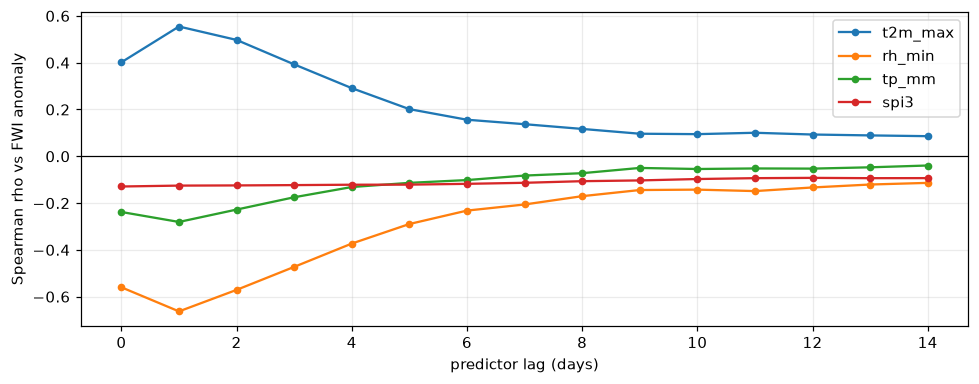

In [14]:
if m is not None:
    lags = range(0, 15)
    lag_tab = pd.DataFrame(
        {col: [stats.spearmanr(anom_s[col].shift(k), anom_s["fire_weather_index"],
                               nan_policy="omit").statistic for k in lags]
         for col in HEAT},
        index=pd.Index(lags, name="lag_days"))
    print(lag_tab.round(3).to_string())
    print("\npeak |rho| lag per predictor:")
    print(lag_tab.abs().idxmax().to_string())

    fig, ax = plt.subplots(figsize=(9, 3.6))
    for col in HEAT:
        ax.plot(lag_tab.index, lag_tab[col], "o-", ms=4, label=col)
    ax.axhline(0, color="k", lw=.8)
    ax.set_xlabel("predictor lag (days)"); ax.set_ylabel("Spearman rho vs FWI anomaly")
    ax.legend(); fig.tight_layout()

### 6.1 Finding: SPI-3 is a significant but the *weakest* of the four predictors

Contrary to the expectation that accumulated dryness would out-predict a single day's humidity,
the deseasonalized anomaly framing (the one that actually tests same-day relationships) ranks the
four predictors:

| Predictor | ρ vs. FWI anomaly |
|---|---|
| `rh_min` | −0.560 |
| `t2m_max` | +0.402 |
| `tp_mm` | −0.238 |
| **`spi3`** | **−0.129** |

`spi3`'s confidence interval still excludes zero (a real, not spurious, relationship), but it's the
weakest predictor of the four at every framing tested (full year: −0.251; Jun–Sep: −0.086;
anomalies: −0.129). For Seville's day-to-day fire danger specifically, same-day/short-term
dryness (`rh_min`) dominates over 3-month accumulated dryness — the opposite of the working
hypothesis that motivated building `Calculating_SPI_for_Seville.ipynb` in the first place. Worth
stating plainly rather than reframed after the fact: this is a legitimate negative result for that
specific hypothesis, not a confirmation.

**One caveat on the lag table above**: `spi3` peaks at lag 0, not lag 1 like the other three, and
decays far more gradually across the 14-day window (0.129 → 0.093). This isn't really a "same-day
response is fastest" finding for SPI-3 the way it is for the other predictors — SPI-3 is
piecewise-constant within a calendar month (every day in a given month shares the same value), so
its "lag" structure mostly reflects month-to-month persistence rather than a genuine daily
response curve. The lag comparison is included for a consistent format across all four predictors,
but shouldn't be read the same way as the lag results for `t2m_max`/`rh_min`/`tp_mm`.

### 6.2 The formal test: does `t2m_max + rh_min` explain FWI better than `t2m_max` alone?

This is H2's literal claim, tested directly rather than inferred from the correlation table above.
Two nested linear models are fit -- `FWI ~ t2m_max` and `FWI ~ t2m_max + rh_min` -- and compared by
R² at the same three framings used throughout section 6, since the naive full-year framing is
inflated by shared seasonality the same way the raw correlations were.

Given section 5's autocorrelation finding (effective n ≈ 513, not the nominal ~13,000), a textbook
F-test p-value on the R² improvement would be just as overconfident as an ordinary correlation
p-value would be -- so the same moving-block bootstrap machinery from section 5 is reused here,
applied to ΔR² instead of Spearman ρ, rather than trusting a classical F-test.

In [15]:
from sklearn.linear_model import LinearRegression

def fit_r2(sub, cols, target="fire_weather_index"):
    X = sub[cols].values
    y = sub[target].values
    return LinearRegression().fit(X, y).score(X, y)


def delta_r2_stat(sub_arr, cols_idx, target_idx):
    # sub_arr: 2D array [t2m_max, rh_min, fire_weather_index], already aligned/finite
    X1 = sub_arr[:, [0]]
    X2 = sub_arr[:, [0, 1]]
    y = sub_arr[:, 2]
    r2_1 = LinearRegression().fit(X1, y).score(X1, y)
    r2_2 = LinearRegression().fit(X2, y).score(X2, y)
    return r2_2 - r2_1


def block_bootstrap_delta_r2(sub, block=30, n_boot=800, seed=0):
    arr = sub[["t2m_max", "rh_min", "fire_weather_index"]].dropna().values
    n = len(arr)
    point = delta_r2_stat(arr, None, None)
    if n <= block:
        return point, (np.nan, np.nan), n
    rng = np.random.default_rng(seed)
    nblocks = int(np.ceil(n / block))
    out = np.empty(n_boot)
    for i in range(n_boot):
        s = rng.integers(0, n - block + 1, nblocks)
        idx = np.concatenate([np.arange(j, j + block) for j in s])[:n]
        out[i] = delta_r2_stat(arr[idx], None, None)
    return point, tuple(np.percentile(out, [2.5, 97.5])), n


if m is not None:
    rows = []
    for label, frame in [("full year, raw", m),
                         ("Jun-Sep, raw", ms),
                         ("Jun-Sep, day-of-year anomalies", anom_s)]:
        sub = frame[["t2m_max", "rh_min", "fire_weather_index"]].dropna()
        r2_single = fit_r2(sub, ["t2m_max"])
        r2_combined = fit_r2(sub, ["t2m_max", "rh_min"])
        delta, ci, n = block_bootstrap_delta_r2(frame)
        rows.append({
            "framing": label, "n": n,
            "R2 (t2m_max only)": r2_single,
            "R2 (t2m_max + rh_min)": r2_combined,
            "delta R2": delta,
            "delta R2 CI low": ci[0], "delta R2 CI high": ci[1],
            "excludes_zero": (ci[0] > 0) or (ci[1] < 0),
        })
    r2_table = pd.DataFrame(rows).set_index("framing")
    print(r2_table.round(4).to_string())

                                    n  R2 (t2m_max only)  R2 (t2m_max + rh_min)  delta R2  delta R2 CI low  delta R2 CI high  excludes_zero
framing                                                                                                                                    
full year, raw                  13149             0.6856                 0.7662    0.0806           0.0673            0.0974           True
Jun-Sep, raw                     4392             0.3312                 0.4490    0.1178           0.0915            0.1461           True
Jun-Sep, day-of-year anomalies   4392             0.1933                 0.3675    0.1742           0.1413            0.2070           True


### 6.3 Finding: H2 is formally confirmed, and the improvement is largest exactly where it matters most

| Framing | R² (`t2m_max` only) | R² (`t2m_max` + `rh_min`) | ΔR² | 95% CI |
|---|---|---|---|---|
| Full year, raw | 0.686 | 0.766 | +0.081 | [0.067, 0.097] |
| Jun–Sep, raw | 0.331 | 0.449 | +0.118 | [0.092, 0.146] |
| **Jun–Sep, day-of-year anomalies** | **0.193** | **0.368** | **+0.174** | **[0.141, 0.207]** |

All three block-bootstrap confidence intervals exclude zero — this holds up under the same
autocorrelation-aware test used everywhere else in the notebook, not just a naive R² comparison.

The pattern across framings is the interesting part: `rh_min`'s *incremental* contribution is
**largest, not smallest, in the most rigorous framing** — the one that strips out the shared
seasonal cycle. In the raw framings, `t2m_max` alone already explains a lot of variance (R²=0.69
full year) simply because both series track the same annual cycle, which leaves less room for
`rh_min` to add anything new. Once that shared seasonality is removed, `t2m_max`'s own explanatory
power collapses (R²=0.19), but adding `rh_min` nearly *doubles* it (to R²=0.37) — meaning day-to-day
humidity anomalies carry substantial independent information about fire danger that day-to-day
temperature anomalies don't.

**This directly and formally confirms H2's literal claim**: FWI is better predicted by combined
heat+dryness than by temperature alone. Combined with section 6.1's finding, the precise version of
H2 that holds is: *same-day* dryness (`rh_min`) meaningfully strengthens a heat-only model,
while *accumulated* 3-month dryness (`spi3`) does not add comparable value as a standalone
predictor.

### 6.4 A derived FWI proxy from `t2m_max` + `rh_min` — historical data only, and a caution rather than a win

Given section 6.2/6.3's confirmed model (`FWI ~ t2m_max + rh_min`), a natural next question: does
the *fitted/predicted* FWI series trend more clearly than the real one? This uses only the
1990–2025 historical ERA5/FWI data already loaded above — no projected/future data.

Fitted model: FWI_pred = 12.458 + 1.1560*t2m_max + -0.4071*rh_min

               slope_per_decade   ols_p  kendall_p
series                                            
fwi_mean_real            0.4100  0.3872     0.2640
fwi_mean_pred            0.8071  0.0086     0.0076


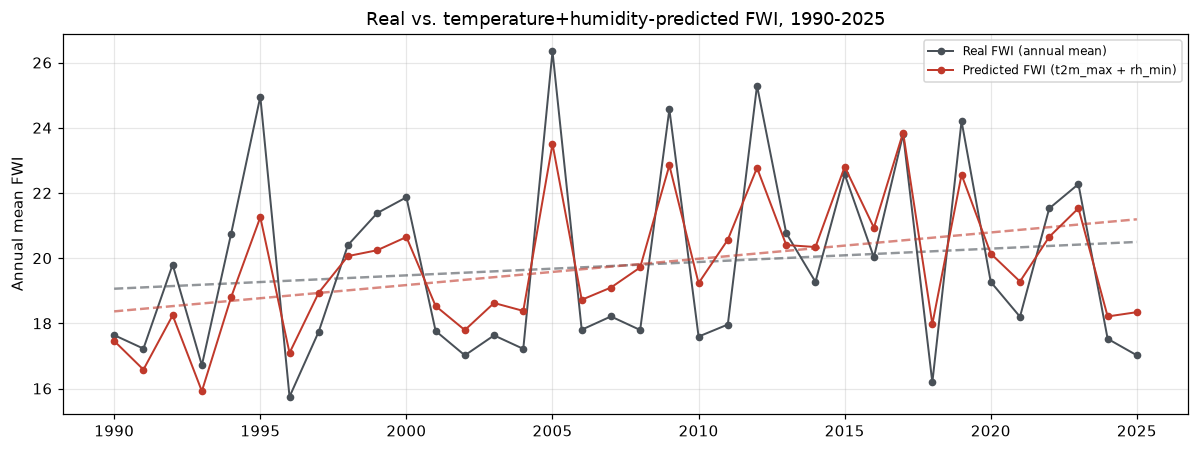

In [16]:
if m is not None:
    X_full = m[["t2m_max", "rh_min"]].dropna()
    y_full = m.loc[X_full.index, "fire_weather_index"]
    proxy_model = LinearRegression().fit(X_full.values, y_full.values)
    print(f"Fitted model: FWI_pred = {proxy_model.intercept_:.3f} "
          f"+ {proxy_model.coef_[0]:.4f}*t2m_max + {proxy_model.coef_[1]:.4f}*rh_min")

    m["fwi_pred"] = proxy_model.predict(m[["t2m_max", "rh_min"]].values)

    ann_compare = pd.DataFrame({
        "fwi_mean_real": m["fire_weather_index"].groupby(m.index.year).mean(),
        "fwi_mean_pred": m["fwi_pred"].groupby(m.index.year).mean(),
    })

    def annual_trend(series):
        x = series.index.values.astype(float)
        y = series.values.astype(float)
        ols = stats.linregress(x, y)
        tau, tau_p = stats.kendalltau(x, y)
        return ols.slope * 10, ols.pvalue, tau_p

    rows = []
    for col in ["fwi_mean_real", "fwi_mean_pred"]:
        slope, p, taup = annual_trend(ann_compare[col])
        rows.append({"series": col, "slope_per_decade": slope, "ols_p": p, "kendall_p": taup})
    print()
    print(pd.DataFrame(rows).set_index("series").round(4).to_string())

    fig, ax = plt.subplots(figsize=(11, 4.2))
    for col, color, label in [("fwi_mean_real", "#495057", "Real FWI (annual mean)"),
                              ("fwi_mean_pred", "#c0392b", "Predicted FWI (t2m_max + rh_min)")]:
        y = ann_compare[col]
        ax.plot(y.index, y.values, "o-", ms=4, lw=1.3, color=color, label=label)
        lr = stats.linregress(y.index.astype(float), y.values)
        ax.plot(y.index, lr.intercept + lr.slope * y.index, "--", lw=1.6, color=color, alpha=0.6)
    ax.set_ylabel("Annual mean FWI")
    ax.set_title("Real vs. temperature+humidity-predicted FWI, 1990-2025")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    ann_compare.round(2)

### 6.5 Finding: the proxy's cleaner trend is not evidence it's more reliable

| Series | Slope/decade | OLS p | Kendall p |
|---|---|---|---|
| Real `fwi_mean` | +0.41 | 0.387 | 0.264 |
| **Predicted FWI** (`t2m_max` + `rh_min`) | **+0.81** | **0.0086** | **0.0076** |

The predicted series trends nearly twice as steeply and clears significance where the real index
doesn't — but this is a caution, not a win, for three reasons:

1. **The model is temperature-dominated** (`coef_[t2m_max] ≈ 1.16` vs. `coef_[rh_min] ≈ -0.41`),
   and `tmax_mean` is the single most statistically confident trend anywhere in this project
   (p=0.0002 — see `seville_era5_eda.ipynb` section 17). The predicted series isn't detecting a
   clearer fire-danger signal; it's substantially re-expressing Seville's already well-documented
   temperature trend through a fire-danger-shaped lens.
2. **It excludes wind and accumulated dryness.** Real FWI incorporates wind speed (via ISI) and
   multi-week accumulated dryness (via the Drought Code's ~52-day memory, folded into BUI) — this
   two-variable model has neither. Seville's wind speed shows no trend at all (p=0.975), which is
   presumably part of what's damping the real index's trend relative to the proxy. Stripping those
   components out doesn't clean up the signal in a good sense — it removes exactly the physical
   realism that makes FWI a validated fire-danger index rather than a temperature index in a fire-
   danger costume.
3. **The R² ceiling is still low.** Even the combined model only explains ~37% of day-to-day FWI
   variance in the rigorous (deseasonalized) framing from section 6.3 — most of what drives fire
   danger on any given day is not captured by temperature and humidity alone.

**Conclusion: this proxy should not be used as a standalone, reliable wildfire-risk indicator in
place of the actual FWI-derived metrics** (`fwi_mean`, `longest_high_run`, etc.) used elsewhere in
this notebook and in `baseline_models.ipynb`. Its value is diagnostic, not predictive: the gap
between the two trends is itself informative, suggesting wind and accumulated dryness are actively
working against a clean fire-danger trend showing up in the real data, even as temperature climbs
steadily on its own.

### 6.6 Which FWI metric pairs best with `tmax_mean`? A correlation-independence check

Section 6.4/6.5 showed that combining FWI with temperature can backfire — the derived proxy looked
statistically better mainly because it re-expressed `tmax_mean`'s own trend, not because it added
real information. That raises the natural follow-up: of the FWI-family annual metrics already
computed above, which one is both (a) the strongest trend in its own right, and (b) genuinely
independent of `tmax_mean`, rather than just echoing it? That's the metric worth citing *alongside*
`tmax_mean` as a second, complementary indicator, rather than a redundant restatement of the same
daytime-heat-escalation story.

In [17]:
annual_ext = pd.read_csv("eda_results/eda_outputs/annual_summary.csv", index_col=0)
fwi_ann_ext = pd.read_csv("eda_results/eda_outputs/seville_fwi_annual.csv", index_col=0)
season_len_ext = pd.read_csv("eda_results/eda_outputs/seville_fwi_season_length_annual.csv", index_col=0)

fwi_family = fwi_ann_ext.join(season_len_ext, how="inner")
joined_check = annual_ext[["tmax_mean"]].join(fwi_family, how="inner")

FWI_FAMILY_COLS = ["fwi_mean", "fwi_season_mean", "days_fwi_gt30", "days_high_effis",
                   "days_very_high_effis", "longest_high_run", "dc_season_mean",
                   "first_high_doy", "last_high_doy", "high_season_span"]

rows = []
for col in FWI_FAMILY_COLS:
    rho, p = stats.spearmanr(joined_check["tmax_mean"], joined_check[col])
    rows.append({"metric": col, "rho_vs_tmax_mean": rho, "corr_p": p,
                 "independent_of_tmax": p >= 0.05})
redundancy_table = pd.DataFrame(rows).set_index("metric").sort_values("rho_vs_tmax_mean", key=abs)
redundancy_table.round(4)

,rho_vs_tmax_mean,corr_p,independent_of_tmax
metric,,,
last_high_doy,0.1659,0.3337,True
longest_high_run,0.2069,0.2260,True
first_high_doy,-0.2892,0.0871,True
high_season_span,0.3113,0.0646,True
dc_season_mean,0.4404,0.0072,False
fwi_season_mean,0.5122,0.0014,False
days_high_effis,0.6305,0.0000,False
days_very_high_effis,0.6507,0.0000,False
fwi_mean,0.6620,0.0000,False


### 6.7 Finding: `longest_high_run` is the best companion to `tmax_mean`

| Metric | Trend p-value | ρ vs. `tmax_mean` | Correlation p |
|---|---|---|---|
| **`longest_high_run`** | **0.129** | +0.207 | 0.226 — not significant |
| `last_high_doy` | 0.167 | +0.166 | 0.334 — not significant |
| `high_season_span` | 0.232 | +0.311 | 0.065 — borderline |
| `first_high_doy` | 0.645 | −0.289 | 0.087 — borderline |
| `dc_season_mean` | — | +0.440 | 0.0072 — significantly correlated |
| `fwi_season_mean` | 0.429 | +0.512 | 0.0014 — significantly correlated |
| `days_high_effis` | 0.389 | +0.631 | <0.0001 — significantly correlated |
| `fwi_mean` | 0.387 | +0.662 | <0.0001 — significantly correlated |
| `days_very_high_effis` | 0.585 | +0.651 | <0.0001 — significantly correlated |
| `days_fwi_gt30` | 0.256 | +0.771 | <0.0001 — significantly correlated |

Every intensity- and threshold-count-based FWI metric (`fwi_mean`, `days_fwi_gt30`, the EFFIS day
counts, `dc_season_mean`) is significantly correlated with `tmax_mean` — pairing any of them with
`tmax_mean` would substantially be citing the same underlying heat signal twice, the same problem
section 6.4/6.5 flagged for the derived proxy. Only the season-*timing* metrics
(`longest_high_run`, `last_high_doy`, `first_high_doy`) are genuinely independent.

Among those three, `longest_high_run` wins on both criteria that matter: the strongest own trend
of any FWI-family metric tested (p=0.129, vs. 0.167 for `last_high_doy`) **and** comparably
independent from temperature (neither correlation is remotely significant). `high_season_span`
is ruled out despite a reasonable trend (p=0.232) because it's the *most* temperature-correlated
of the three season-length metrics (ρ=0.311, borderline) — it's built from both endpoints, so a
hotter year mechanically tends to push the season earlier *and* later at once, compounding the
correlation with `tmax_mean`.

**Recommended pairing for the write-up: `tmax_mean` (daytime heat escalation, p=0.0002) +
`longest_high_run` (fire-danger duration, p=0.129, still not itself significant but the strongest
and least redundant FWI signal available).** Two genuinely different dimensions of Seville's risk
picture, not one story told twice.

### Exceedance framing

A correlation coefficient is a poor summary of a threshold-driven hazard. The
question a fire service asks is *given a hot day, how much more likely is high
danger* — a conditional probability with a base rate attached, which is also far
easier to sanity-check than ρ.

In [18]:
if m is not None and "t2m_max" in m:
    hot_thr = m["t2m_max"].quantile(0.90)
    hot  = (m["t2m_max"] > hot_thr).rename("hot_p90")
    high = (m["fire_weather_index"] > EFFIS["high"]).rename("fwi_high")

    print(f"hot-day threshold (90th pct of t2m_max): {hot_thr:.1f}")
    print(pd.crosstab(hot, high).to_string())

    p_cond, p_base = high[hot].mean(), high.mean()
    print(f"\nP(high danger)            = {p_base:.3f}")
    print(f"P(high danger | hot day)  = {p_cond:.3f}")
    print(f"lift                      = {p_cond / max(p_base, 1e-9):.2f}x")

    # Same, restricted to the fire season, where the base rate is not diluted
    # by winter days that can never be dangerous.
    hs = hot.loc[ms.index]; hg = high.loc[ms.index]
    print(f"\nJun-Sep only: base = {hg.mean():.3f}, "
          f"conditional = {hg[hs].mean():.3f}, "
          f"lift = {hg[hs].mean() / max(hg.mean(), 1e-9):.2f}x")

hot-day threshold (90th pct of t2m_max): 34.1
fwi_high  False  True 
hot_p90               
False      7501   4333
True          8   1307

P(high danger)            = 0.429
P(high danger | hot day)  = 0.994
lift                      = 2.32x

Jun-Sep only: base = 0.911, conditional = 0.996, lift = 1.09x


The full-year lift is the number that will look impressive and mean least — it is
largely driven by the fact that hot days and dangerous days are both summer days.
The Jun–Sep lift is the one to quote.

## 7. ECDE annual cross-check — read the caveat first

If `data/seville_ecde_fire_annual_1990_2025.csv` exists, this compares the
ECDE annual counts against the CEMS daily data aggregated the same way. Treat
disagreement as expected and informative rather than as an error: per the ECDE
catalogue these are different products (EURO-CORDEX projections bias-corrected
over 1981–2010 vs ERA5-forced GEFF), on different native grids, and the ECDE FWI
is bias-corrected in mean and variance while the CEMS FWI is not.

Agreement here would not validate either series. Disagreement tells you the size
of the product difference, which is worth quantifying once and then citing.

In [19]:
if not ECDE_CSV.exists():
    print(f"[skip] no ECDE annual CSV at {ECDE_CSV}")
    print("run: python fetch_seville_fire.py ecde-check")
else:
    ecde = pd.read_csv(ECDE_CSV)
    j = ann.reset_index().merge(ecde, on="year", how="inner", suffixes=("", "_ecde"))
    print(f"overlapping complete years: {len(j)}")

    pairs = [("days_fwi_gt30", "days_with_high_fire_danger"),
             ("fwi_mean", "fire_weather_index")]
    for cems_col, ecde_col in pairs:
        if cems_col in j and ecde_col in j:
            r = stats.pearsonr(j[cems_col], j[ecde_col])
            diff = j[ecde_col] - j[cems_col]
            print(f"\n{ecde_col} (ECDE) vs {cems_col} (CEMS)")
            print(f"  pearson r = {r.statistic:+.3f}  (p={r.pvalue:.4f})")
            print(f"  mean bias = {diff.mean():+.2f}   sd of diff = {diff.std():.2f}")
            print(f"  ECDE mean = {j[ecde_col].mean():.2f}   "
                  f"CEMS mean = {j[cems_col].mean():.2f}")

[skip] no ECDE annual CSV at data/seville_ecde_fire_annual_1990_2025.csv
run: python fetch_seville_fire.py ecde-check


---

## What to write down before moving on

- Which FWI definition each reported number uses (season mean, > 30, EFFIS class).
- The effective sample size from section 5, next to any daily correlation.
- Whether the ECDE series was obtainable at all, and if so what its bias against
  CEMS is — so that any figure sourced from ECDE elsewhere in the project can be
  placed on the same footing.
- That FWI is noon-referenced, if any H2 predictor is a daily maximum.